In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

import seaborn as sns

def custom_grouping(index):
    return index // 1000

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

In [2]:
cmr_zipf_9010_1M_bw = 98.39  # MiB/s
cmr_uniform_1M_bw = 81.05  # MiB/s
cmr_zipf_9010_4K_bw = 2.46  # MiB/s 
cmr_uniform_4K_bw = 1.26  # MiB/s

# Series colors hash
series_colors = {
    "hasmr": "#56B4E9",
    "dmhybrid": "#CC79A7",
    "hmhybrid": "#009E73",
    "cmr": "#E69F00",
    "hmls": "#0072B2"
}

# Reference line colors hash
ref_line_colors = {
    "PRE": "#000000",
    "POST": "#666666",
    "TIME": "#999999",
    "CMR": "#332288"
}

# Reference line styles hash
ref_line_styles = {
    "PRE": "-",
    "POST": "--",
    "TIME": ":",
    "CMR": "-."
}

In [3]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('fast2026/STL/4K/uniform/sda/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

             index  data_written_bytes  cumulative_gb
count  4452.000000         4452.000000    4452.000000
mean   2225.500000            0.183741       0.744201
std    1285.326029            1.175152       0.067563
min       0.000000            0.000000       0.004653
25%    1112.750000            0.023202       0.723819
50%    2225.500000            0.025102       0.750821
75%    3338.250000            0.026414       0.777465
max    4451.000000            9.456908       0.798843
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4452 entries, 0 to 4451
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               4452 non-null   int64  
 1   data_written_bytes  4452 non-null   float64
 2   cumulative_gb       4452 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 104.5 KB
None
Average1: 0
Average2: 9


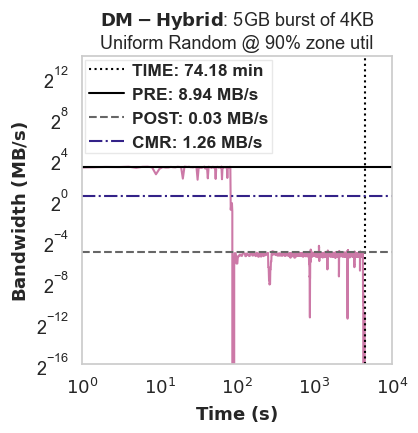

In [6]:
"""Vectorized approach - fastest for most datasets"""

# Step 3: Determine time range
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Pre-compute all values vectorized
df_vec = df.copy()
df_vec['duration'] = df_vec['duration'].astype(float)
df_vec['start'] = df_vec['submission_time'].astype(int)
df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

payload = 4096  # 4KB
df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)
##################################

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_grouped_vec.reset_index(inplace=True)
df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped_vec.describe())
print(df_grouped_vec.info())

####################

data_array_vec = df_grouped_vec['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array_vec)
# Get the cluster centers
cluster_centers_vec = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers_vec.sort()
# Calculate the average of each mode
average_mode1_vec = cluster_centers_vec[0]
average_mode2_vec = cluster_centers_vec[1]
print("Average1: " + str(round(average_mode1_vec, )))
print("Average2: " + str(round(average_mode2_vec, )))
avg_bw_str1 = str(round(average_mode1_vec, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'

####################
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(4, 4))

plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color= series_colors['dmhybrid'], linewidth=1.5)
plt.title(r"$\bf{DM-Hybrid}$: 5GB burst of 4KB" "\n" r"Uniform Random @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**4)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped_vec.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2_vec, color=ref_line_colors['PRE'], linestyle=ref_line_styles['PRE'], label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1_vec, color=ref_line_colors['POST'], linestyle=ref_line_styles['POST'], label='POST: ' + avg_bw_str1)
plt.axhline(y=cmr_uniform_4K_bw, color=ref_line_colors['CMR'], linestyle=ref_line_styles['CMR'], label='CMR: ' + str(cmr_uniform_4K_bw) + ' MB/s')
# plt.legend(loc='upper left', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13 )

plt.legend(
    loc='upper left',
    bbox_to_anchor=(0, 1),
    prop={'size': 12.5, 'weight': 'semibold'},
    borderaxespad=0.2,              # no padding between axes and legend box
    borderpad=0.2,                  # minimal padding inside legend frame
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.5,
    edgecolor='lightgray',
    fontsize=12.5,
    markerscale=0.7,        # scales down marker size
    handlelength=2,         # length of line in legend
    handletextpad=0.5       # spacing between line and text
)

plt.savefig('figs/4K_90Util_Uniform_DMHybrid_BWTime.pdf', bbox_inches='tight',dpi=500)
plt.show()

## 1MB Uniform Random, 90% Zone Utilization


In [7]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('fast2026/STL/1M/uniform/90Util/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

             index  data_written_bytes  cumulative_gb
count  4781.000000         4781.000000    4781.000000
mean   2390.000000            9.638151      35.320229
std    1380.300149           24.809667       7.165016
min       0.000000            0.000000       0.090748
25%    1195.000000            3.765767      31.522734
50%    2390.000000            3.968532      36.055612
75%    3585.000000            4.215448      40.550246
max    4780.000000          153.480628      45.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4781 entries, 0 to 4780
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               4781 non-null   int64  
 1   data_written_bytes  4781 non-null   float64
 2   cumulative_gb       4781 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 112.2 KB
None
Average1: 4
Average2: 116


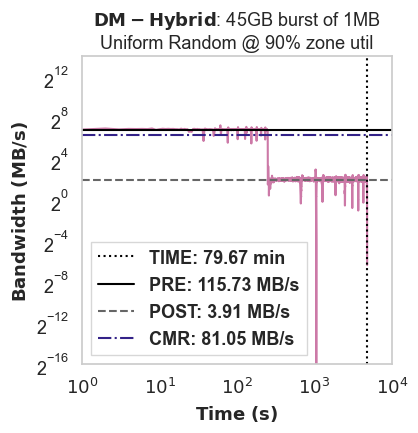

In [8]:
"""Vectorized approach - fastest for most datasets"""

# Step 3: Determine time range
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Pre-compute all values vectorized
df_vec = df.copy()
df_vec['duration'] = df_vec['duration'].astype(float)
df_vec['start'] = df_vec['submission_time'].astype(int)
df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

payload = 1024*1024  # 1MB
df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)
##################################

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_grouped_vec.reset_index(inplace=True)
df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped_vec.describe())
print(df_grouped_vec.info())

####################

data_array_vec = df_grouped_vec['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array_vec)
# Get the cluster centers
cluster_centers_vec = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers_vec.sort()
# Calculate the average of each mode
average_mode1_vec = cluster_centers_vec[0]
average_mode2_vec = cluster_centers_vec[1]
print("Average1: " + str(round(average_mode1_vec, )))
print("Average2: " + str(round(average_mode2_vec, )))
avg_bw_str1 = str(round(average_mode1_vec, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'

####################
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(4, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color= series_colors['dmhybrid'], linewidth=1.5)
plt.title(r"$\bf{DM-Hybrid}$: 45GB burst of 1MB" "\n" r"Uniform Random @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**4)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped_vec.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2_vec, color=ref_line_colors['PRE'], linestyle=ref_line_styles['PRE'], label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1_vec, color=ref_line_colors['POST'], linestyle=ref_line_styles['POST'], label='POST: ' + avg_bw_str1)
plt.axhline(y=cmr_uniform_1M_bw, color=ref_line_colors['CMR'], linestyle=ref_line_styles['CMR'], label='CMR: ' + str(cmr_uniform_1M_bw) + ' MB/s')
plt.legend(loc='lower left', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
           shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13 )

plt.savefig('figs/1M_90Util_Uniform_DMHybrid_BWTime.pdf', bbox_inches='tight',dpi=500)
plt.show()